In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from SciServer import Authentication, CasJobs
from astroquery.ipac.ned import Ned
from astropy.cosmology import LambdaCDM

# Part 1 - Shen et al (2011) sample

## SDSS cross-match

In [2]:
data = pd.read_csv('shen_subsample_500.csv') # read the sample

In [3]:
data.head()

,RAJ2000,DEJ2000,Plate,Fiber,MJD,iMAG,logLbol,e_logLbol,logLBHb,e_logLBHb,W_BHb_,e_W_BHb_,EWBHb,e_EWBHb,SN_Hb_,logBH,e_logBH,logEdd
0,189.67804,45.30687,1372,486,53062,-23.20,45.236,0.004,42.35,0.02,4399.3,330.1,62.0,3.1,23.06,8.33,0.07,-1.20
1,189.77188,41.44564,1984,609,53433,-22.29,44.819,0.005,42.11,0.04,2371.4,541.6,89.4,8.7,15.06,7.59,0.20,-0.87
2,189.81419,53.23740,885,449,52379,-22.69,45.121,0.004,41.93,0.04,10756.6,4366.4,32.1,3.4,16.27,9.05,0.35,-2.03
3,189.93733,19.90707,2614,350,54481,-23.37,45.132,0.001,42.55,0.02,15241.3,362.8,118.7,6.3,19.79,9.36,0.02,-2.33
4,189.99405,49.09448,1278,96,52735,-22.77,45.166,0.011,42.25,0.01,1385.6,48.6,52.5,2.9,15.96,7.29,0.03,-0.23


Now we extract the SDSS spectral identification numbers (mjd, plate, fiber) to cross-match the objects.

In [4]:
# Create String of the form (index, plate, mjd, fiberid), (index2, plate2, mjd2, fiberid2) ... for each row in the dataframe
values = ', '.join([f"({data.index[i]}, {row['Plate']}, {row['MJD']}, {row['Fiber']})" for i, row in data.iterrows()])

In [5]:
print(values)

(0, 1372.0, 53062.0, 486.0), (1, 1984.0, 53433.0, 609.0), (2, 885.0, 52379.0, 449.0), (3, 2614.0, 54481.0, 350.0), (4, 1278.0, 52735.0, 96.0), (5, 2237.0, 53828.0, 448.0), (6, 1372.0, 53062.0, 589.0), (7, 2614.0, 54481.0, 279.0), (8, 846.0, 52407.0, 119.0), (9, 846.0, 52407.0, 596.0), (10, 1789.0, 54259.0, 190.0), (11, 1790.0, 53876.0, 217.0), (12, 1985.0, 53431.0, 429.0), (13, 2601.0, 54144.0, 271.0), (14, 1975.0, 53734.0, 180.0), (15, 1790.0, 53876.0, 472.0), (16, 522.0, 52024.0, 408.0), (17, 2601.0, 54144.0, 378.0), (18, 2239.0, 53726.0, 239.0), (19, 495.0, 51988.0, 333.0), (20, 1373.0, 53063.0, 434.0), (21, 2022.0, 53827.0, 553.0), (22, 1317.0, 52765.0, 98.0), (23, 1987.0, 53765.0, 464.0), (24, 886.0, 52381.0, 396.0), (25, 1987.0, 53765.0, 164.0), (26, 1455.0, 53089.0, 68.0), (27, 847.0, 52426.0, 558.0), (28, 847.0, 52426.0, 602.0), (29, 495.0, 51988.0, 207.0), (30, 2661.0, 54505.0, 197.0), (31, 1987.0, 53765.0, 82.0), (32, 2601.0, 54144.0, 575.0), (33, 1770.0, 53171.0, 58.0), (34,

Next we query from SDSS using CasJobs:

In [ ]:
Authentication.login('','')

query = f'''
        CREATE TABLE #upload (up_id int, up_plate int, up_mjd int, up_fiberid int)
        INSERT INTO #upload values {values}

        SELECT 
        s.specobjid, s.z,
        s.plate, s.mjd, s.fiberid,
        g.h_beta_flux,
        2.3548 * sigma_balmer AS fwhm_hbeta
        
        FROM #upload AS u
        JOIN SpecObj AS s ON (s.plate = u.up_plate AND s.mjd = u.up_mjd AND s.fiberid = u.up_fiberid)
        JOIN GalSpecLine as g ON s.specobjid = g.specobjid
'''

In [7]:
result = CasJobs.executeQuery(query, context='DR19')

In [8]:
result.head()

,specobjid,z,plate,mjd,fiberid,h_beta_flux,fwhm_hbeta
0,381805716010199040,0.250060,339,51692,457,65.61485,189.9683
1,1934430794722338816,0.284854,1718,53850,490,245.46820,1177.4000
2,2987114778402514944,0.290483,2653,54230,372,170.44200,1177.4000
3,1310613232246876160,0.209694,1164,52674,239,210.37060,1177.4000
4,1311807027483273216,0.211253,1165,52703,486,410.23340,1177.4000


In [9]:
print(f'Found {len(result)} objects in SDSS from the Shen et al (2011) sample')

Found 428 objects in SDSS from the Shen et al (2011) sample


In [10]:
data.rename(columns={'Plate': 'plate', 'MJD': 'mjd', 'Fiber': 'fiberid'}, inplace=True)
complete_data = pd.merge(data, result, on=['plate', 'mjd', 'fiberid'], how='inner')

In [11]:
complete_data.head()

,RAJ2000,DEJ2000,plate,fiberid,mjd,iMAG,logLbol,e_logLbol,logLBHb,e_logLBHb,...,EWBHb,e_EWBHb,SN_Hb_,logBH,e_logBH,logEdd,specobjid,z,h_beta_flux,fwhm_hbeta
0,189.67804,45.30687,1372,486,53062,-23.20,45.236,0.004,42.35,0.02,...,62.0,3.1,23.06,8.33,0.07,-1.20,1544868314222716928,0.228846,323.90260,1177.4000
1,189.77188,41.44564,1984,609,53433,-22.29,44.819,0.005,42.11,0.04,...,89.4,8.7,15.06,7.59,0.20,-0.87,2233952873417304064,0.178252,448.13070,1177.4000
2,189.81419,53.23740,885,449,52379,-22.69,45.121,0.004,41.93,0.04,...,32.1,3.4,16.27,9.05,0.35,-2.03,996544877648963584,0.201624,86.80108,680.4231
3,189.93733,19.90707,2614,350,54481,-23.37,45.132,0.001,42.55,0.02,...,118.7,6.3,19.79,9.36,0.02,-2.33,2943198638932781056,0.239360,370.09130,533.4928
4,189.99405,49.09448,1278,96,52735,-22.77,45.166,0.011,42.25,0.01,...,52.5,2.9,15.96,7.29,0.03,-0.23,1438926515109652480,0.235311,589.24180,976.0384


In [12]:
complete_data.columns

Index(['RAJ2000', 'DEJ2000', 'plate', 'fiberid', 'mjd', 'iMAG', 'logLbol',
       'e_logLbol', 'logLBHb', 'e_logLBHb', 'W_BHb_', 'e_W_BHb_', 'EWBHb',
       'e_EWBHb', 'SN_Hb_', 'logBH', 'e_logBH', 'logEdd', 'specobjid', 'z',
       'h_beta_flux', 'fwhm_hbeta'],
      dtype='str')

In [13]:
# Save final table
#complete_data.to_csv('shen_subsample500_sdss.csv', index=False)
complete_data = pd.read_csv('shen_subsample_500_sdss.csv')

## Data exploration

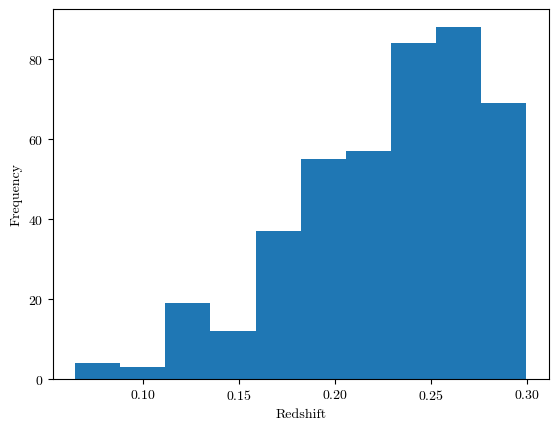

In [14]:
plt.hist(complete_data['z'], bins=10)
plt.xlabel('Redshift')
plt.ylabel('Frequency')
plt.show()

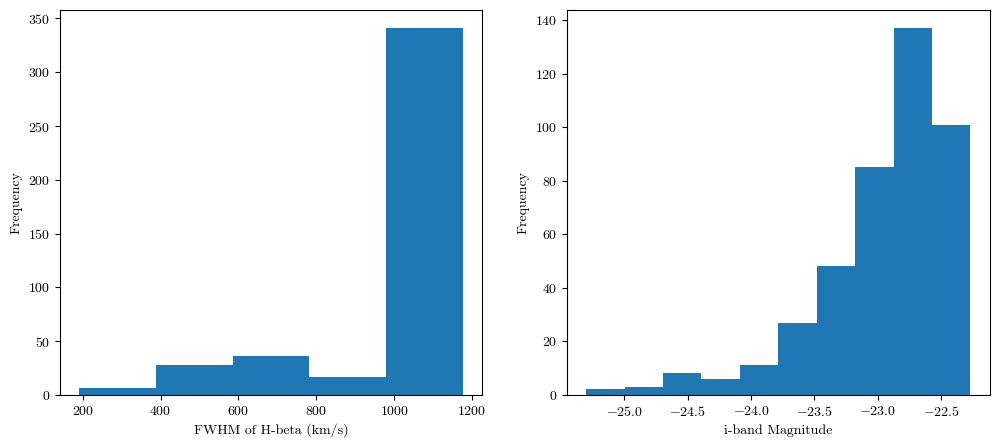

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(complete_data['fwhm_hbeta'], bins=5)
axes[0].set_xlabel('FWHM of H-beta (km/s)')
axes[0].set_ylabel('Frequency')

axes[1].hist(complete_data['iMAG'], bins=10)
axes[1].set_xlabel('i-band Magnitude')
axes[1].set_ylabel('Frequency')

plt.show()

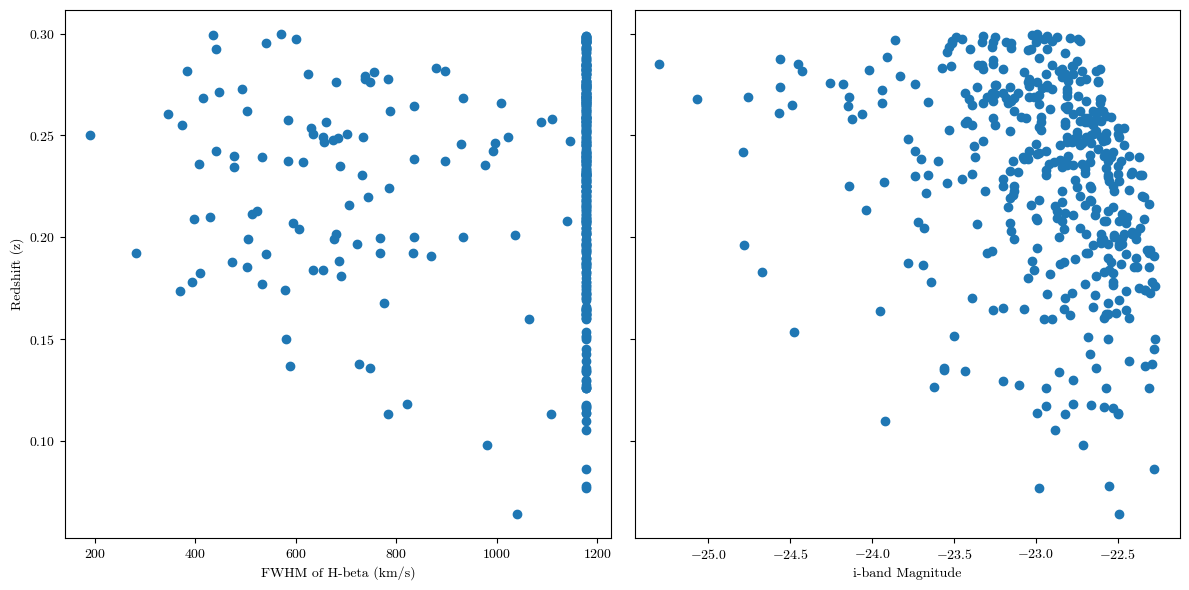

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6),sharey=True)

axes[0].scatter(complete_data['fwhm_hbeta'],complete_data['z'])
axes[0].set_ylabel('Redshift (z)')
axes[0].set_xlabel('FWHM of H-beta (km/s)')

axes[1].scatter(complete_data['iMAG'],complete_data['z'])
axes[1].set_xlabel('i-band Magnitude')

plt.tight_layout()
plt.show()

The sample is biased toward high-luminosity quasars and shows a strong FWHM peak near 1000–1200 km/s, limiting the dynamic range of both luminosity and line-width available for BH mass estimation.

## $\text{H}\beta$ emission line luminosity

In [17]:
# Define cosmology 
cosmo = LambdaCDM(H0=67.8, Om0=0.31, Ode0=0.69)

# Luminosity distance
complete_data['d_L_Mpc'] = complete_data['z'].apply(lambda z: cosmo.luminosity_distance(z).value)  # in Mpc
complete_data['d_L_cm']  = complete_data['d_L_Mpc'] * 3.085677581e24  # convert Mpc to cm

# H-beta luminosity
flux_cgs = complete_data['h_beta_flux'] * 1e-17  # erg/s/cm^2

complete_data['logLHb_sdss'] = np.log10(4 * np.pi * complete_data['d_L_cm']**2 * flux_cgs)  # log(erg/s)

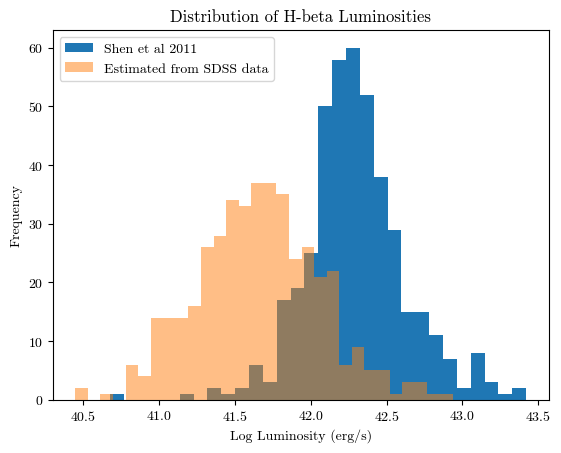

In [18]:
plt.hist(complete_data['logLBHb'], bins=30, label='Shen et al 2011')
plt.hist(complete_data['logLHb_sdss'], bins=30, alpha=0.5, label='Estimated from SDSS data')
plt.xlabel('Log Luminosity (erg/s)')
plt.ylabel('Frequency')
plt.title('Distribution of H-beta Luminosities')
plt.legend()
plt.show()

In [19]:
np.mean(complete_data['logLHb_sdss'])

np.float64(41.65776314900459)

A possible explanation for the discrepancy is that the sample from Shen et al (2011) reports the **Broad** $\text{H}\beta$ line luminosity. However `GalSpecLine` fits a single Gaussian to all emission lines, which systematically underestimates the flux of broad, low-contrast lines in quasars. the flux extracted from SDSS likely contains the toal only the narrow component luminosity.

## Black Hole Mass

Now we estimate the BH mass using the empirical relation from Greene & Ho (2005a):

$$ M_{BH} = 2.4\times 10^6\left( \frac{L_{\text{H}\beta}}{10^{42} \text{ergs s}^{-1}} \right)^{0.59} \left( \frac{\text{FWHM}_{\text{H}\beta}}{10^3 \text{km s}^{-1}} \right)^2 \text{M}_{\odot}$$

Wu (2009) uses this relation specifically for broad-line CSS sources where optical continuum measurements are available and not heavily contaminated by jet emission.

In [20]:
def BH_greene(L_Hbeta, fwhm_hbeta):
    return 2.4e6 * (L_Hbeta/10**42)**(0.59) * (fwhm_hbeta/1000)**2 # Solar mass

complete_data['BH_sdss'] = BH_greene(10**complete_data['logLHb_sdss'], complete_data['fwhm_hbeta'])

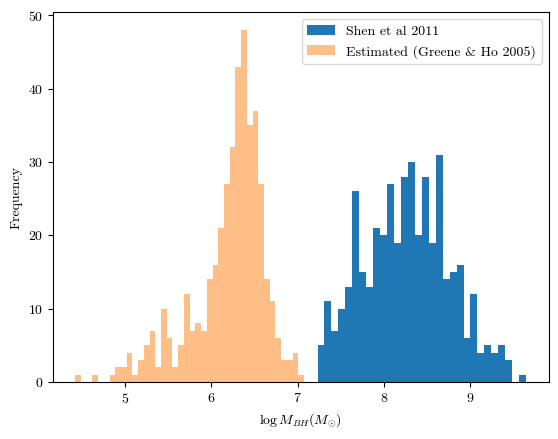

In [21]:
plt.hist(complete_data['logBH'], bins=30, label='Shen et al 2011')
plt.hist(np.log10(complete_data['BH_sdss']), bins=40,label='Estimated (Greene & Ho 2005)',alpha=0.5)
plt.xlabel(r'$\log M_{BH} (M_{\odot})$')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [22]:
np.mean(np.log10(complete_data['BH_sdss']))

np.float64(6.200414854068547)

## Eddington Ratio

To compute the Eddington Ratio we need the Bolometric luminosity of the $\text{H}\beta$ line, for which we use the relation from Wu et al (2009):

$$\log L_{\text{bol}} = (0.94 \pm 0.03)\log L_{\text{H}\beta} + (5.39 \pm 1.14)$$

This relation is derived by fiting the bolometric luminosities (assuming $L_{\text{bol}}​=9L_{5100}​)$ against broad-line luminosities for 35 radio-quiet AGN from Kaspi et al. (2005), where the optical emission is free from jet contamination.

The Eddington Ratio is then calculated with $L_{\text{bol}}/L_{\text{Edd}}$, where $L_{\text{edd}} = 1.38 \times 10^{38} \text{M}_{\text{BH}}/\text{M}_{\odot}$

In [23]:
Edd_L = 1.38e38  # erg/s per solar mass

complete_data['logLBol_sdss'] = (0.94) * complete_data['logLHb_sdss'] + (5.39) 
complete_data['Edd_sdss'] = (10**complete_data['logLBol_sdss'] / (Edd_L * complete_data['BH_sdss']))

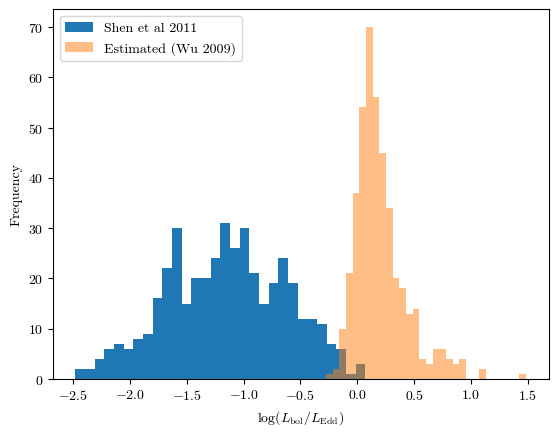

In [24]:
plt.hist(complete_data['logEdd'], bins=30, label='Shen et al 2011')
plt.hist(np.log10(complete_data['Edd_sdss']), bins=30,label='Estimated (Wu 2009)',alpha=0.5)
plt.xlabel(r'$\log (L_{\text{bol}}/L_{\text{Edd}})$')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [25]:
np.mean(np.log10(complete_data['Edd_sdss']))

np.float64(0.20800341959452504)

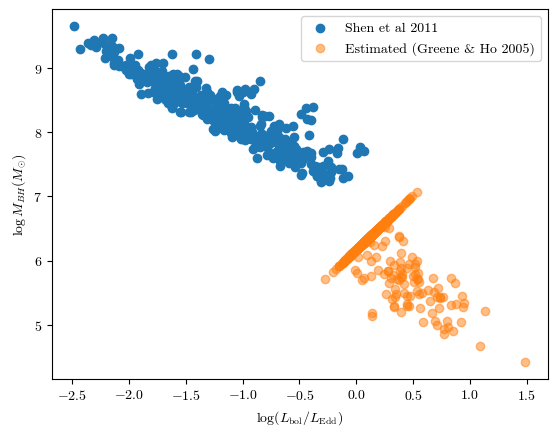

In [26]:
plt.scatter(complete_data['logEdd'], complete_data['logBH'], label='Shen et al 2011')
plt.scatter(np.log10(complete_data['Edd_sdss']), np.log10(complete_data['BH_sdss']), label='Estimated (Greene & Ho 2005)', alpha=0.5)
plt.xlabel(r'$\log (L_{\text{bol}}/L_{\text{Edd}})$')
plt.ylabel(r'$\log M_{BH} (M_{\odot})$')
plt.legend()
plt.show()

The estimated BH masses and Eddington ratios are systematically offset from the Shen et al. (2011) reference values. The mean BH mass from our calculation is lower than Shen's, and several objects show  $\log(L_{bol}/L_{Edd}) > 0$ (super-Eddington).

A possible explanation is that the underestimated $L_{H\beta}$ propagates into both derived quantities:
- **BH mass**: $M_{BH} \propto L_{H\beta}^{0.59}$, so the underestimate  in luminosity gives lower mass
- **Eddington ratio**: lower $M_{BH}$ means lower $L_{Edd}$, inflating  $L_{bol}/L_{Edd}$ even as $L_{bol}$ is also underestimated

# Part 2 - Estimation of BH Mass from galactic host Bulge luminosity

For this part we use the data from Wu et al (2009)

In [27]:
data = {
    'name': [
        '3C 43', '3C 48', '3C 67', '3C 93.1', '3C 138', '3C 147', '3C 186',
        '3C 190', '3C 191', '3C 213.1', '3C 216', '3C 241', '3C 268.3',
        '3C 277.1', '3C 286', '3C 287', '3C 293', '3C 298', '3C 303.1',
        '3C 309.1', '3C 343', '3C 346', '3C 380', '3C 454', '3C 455',
        '3C 459', '2342+821', '4C 14.82', 'PKS 0252-71', 'PKS 1151-348',
        'PKS 1221-423', 'PKS 1524-136', 'PKS 1549-79', 'PKS 2004-447',
        'SDSS 1722+565', 'RX J0134-4258', 'TeX 11111+329', 'IRAS 2018-2244'
    ],
    'z': [
        1.459, 0.369, 0.310, 0.244, 0.759, 0.545, 1.063,
        1.195, 1.956, 0.194, 0.670, 1.617, 0.372,
        0.320, 0.849, 1.055, 0.045, 1.439, 0.270,
        0.905, 0.988, 0.162, 0.692, 1.757, 0.543,
        0.220, 0.735, 0.235, 0.563, 0.258,
        0.171, 1.687, 0.152, 0.240,
        0.425, 0.237, 0.189, 0.185
    ],
    'logMBH': [
        9.2, 8.8, 8.1, 7.1, 8.7, 8.7, 8.9,
        7.8, 9.7, 9.1, 7.0, 7.8, 7.8,
        7.6, 8.5, 9.6, 8.0, 10.4, 8.4,
        9.1, 7.5, 8.8, 9.4, 8.6, 8.5,
        8.5, 7.5, 7.9, 8.0, 9.1,
        7.8, 9.1, 8.0, 7.6,
        7.5, 7.6, 7.3, 6.5
    ],
    'logEdd': [
        -1.0, -0.30, -1.52, np.nan, -0.25, -0.90, -0.30,
        -0.13, -1.27, -0.42, -0.30, 0.56, np.nan,
        -0.14, -0.09, -0.85, -1.78, -0.83, np.nan,
        -0.45, 0.14, -2.54, -1.15, -0.58, -1.62,
        np.nan, 0.18, -0.79, np.nan, -1.54,
        np.nan, -0.91, -0.32, -0.26,
        -0.14, 0.01, -0.21, 1.25
    ]
}


df_wu = pd.DataFrame(data)
df_wu.to_csv('wu2009_data.csv', index=False)

## Black Hole Mass from $M_R$

Here we use the relation between the host galaxy absolute magnitude at $R$ band $M_R$ and BH mass proposed by McLure et al. (2002):

$$\log_{10}(M_{\text{BH}}/\text{M}_{\odot}) = -0.5M_R - 2.96$$

In Wu (2009) they use this relation specifically to estimate the central BH masses for the sources without data for broad emission lines or bulge stellar velocity dispersion.

The relation carries several important assumptions:

* **Host Galaxy Overestimation (Bulge vs. Total):** The method uses total galaxy magnitude instead of isolating just the bulge. This overestimates black hole mass for galaxies with prominent disks or bars, though it works decently for elliptical radio galaxies.
* **K-correction uncertainty**: Converting apparent to absolute magnitude requires a K-correction that depends on the assumed SED shape
* **AGN Light Contamination:** Unsubtracted light from the active galactic nucleus (AGN) itself inflates the measured galaxy luminosity, leading to overestimated black hole masses (especially in bright quasars).
* **Redshift Mismatch:** The formula was calibrated on local, low-redshift galaxies ($z \lesssim 0.2$), but it is being applied to distant objects ($z > 1$) where galaxy structures and the black hole-bulge relationship may have evolved.

"the $M_{BH}–L_{\text{bulge}}$ relation holds from $L_{\text{bulge}} \sim 0.01 L*$, all the way up to objects that constitute some of the most massive ellipticals ever formed: $L_{\text{bulge}} \sim 10 L*$." (McLure et al. 2002)

In [ ]:
# NED query for R-band apparent magnitude for objects in the Wu (2009) sample
import time

names = data['name']

def query_object(name):
    result = {'name': name, 'm_R': np.nan}
    try:
        # R apparent magnitude
        phot    = Ned.get_table(name, table='photometry').to_pandas()
        r_mask  =  ((phot['Observed Passband'].str.contains(r'R.*Cousins|Rc', case=False, na=False)) & 
            (phot['Units'] == 'mag')
        )

        r_match = phot[r_mask]['Photometry Measurement']

        if len(r_match) > 0:
            m_R = float(r_match.iloc[0])
            result['m_R'] = m_R

    except Exception as e:
        print(f"  Failed: {name} — {e}")

    return result

records = []
for name in names:
    print(f"Querying: {name}")
    records.append(query_object(name))
    time.sleep(0.3)

df_wu = df_wu.merge(pd.DataFrame(records), on='name', how='left')
df_wu.to_csv('wu2009_data_with_mR.csv', index=False)

Querying: 3C 43
Querying: 3C 48
Querying: 3C 67
Querying: 3C 93.1
Querying: 3C 138
Querying: 3C 147
Querying: 3C 186
Querying: 3C 190
Querying: 3C 191
Querying: 3C 213.1
Querying: 3C 216
Querying: 3C 241
Querying: 3C 268.3
Querying: 3C 277.1
Querying: 3C 286
Querying: 3C 287
Querying: 3C 293
Querying: 3C 298
Querying: 3C 303.1
Querying: 3C 309.1
Querying: 3C 343
Querying: 3C 346
Querying: 3C 380
Querying: 3C 454
Querying: 3C 455
Querying: 3C 459
Querying: 2342+821
Querying: 4C 14.82
Querying: PKS 0252-71
Querying: PKS 1151-348
  Failed: PKS 1151-348 — Failed to parse NED result! The raw response can be found in self.response, and the error in self.table_parse_error.
Querying: PKS 1221-423
  Failed: PKS 1221-423 — Failed to parse NED result! The raw response can be found in self.response, and the error in self.table_parse_error.
Querying: PKS 1524-136
  Failed: PKS 1524-136 — Failed to parse NED result! The raw response can be found in self.response, and the error in self.table_parse_er

In [29]:
df_wu.head()

,name,z,logMBH,logEdd,m_R
0,3C 43,1.459,9.2,-1.00,NaN
1,3C 48,0.369,8.8,-0.30,NaN
2,3C 67,0.310,8.1,-1.52,NaN
3,3C 93.1,0.244,7.1,NaN,NaN
4,3C 138,0.759,8.7,-0.25,16.9


In [30]:
df_wu_final = df_wu.dropna(subset=['m_R']).reset_index(drop=True)
df_wu_final

,name,z,logMBH,logEdd,m_R
0,3C 138,0.759,8.7,-0.25,16.900
1,3C 186,1.063,8.9,-0.30,16.840
2,3C 190,1.195,7.8,-0.13,17.470
3,3C 213.1,0.194,9.1,-0.42,18.390
4,3C 216,0.670,7.0,-0.30,16.720
5,3C 268.3,0.372,7.8,NaN,19.580
6,3C 286,0.849,8.5,-0.09,15.990
7,3C 287,1.055,9.6,-0.85,16.500
8,3C 293,0.045,8.0,-1.78,12.803
9,3C 303.1,0.270,8.4,NaN,17.910


In [31]:
# Convert to absolute magnitude
def apparent_to_absolute(m_R, z):
    """Convert apparent to absolute R magnitude with K-correction"""
    d_L_Mpc = cosmo.luminosity_distance(z).value
    
    # Distance modulus
    mu = 5 * np.log10(d_L_Mpc * 1e6 / 10)  # d in parsecs
    
    # K-correction for power-law AGN SED: f_nu ~ nu^alpha
    alpha = -0.5
    K = -2.5 * (1 + alpha) * np.log10(1 + z)
    
    M_R = m_R - mu - K
    return M_R

df_wu_final['M_R'] = df_wu_final.apply(lambda row: apparent_to_absolute(row['m_R'], row['z']), axis=1)

In [32]:
df_wu_final['log_MBH_scaling'] = df_wu_final.apply(lambda row: -0.5*row['M_R'] - 2.96, axis=1)

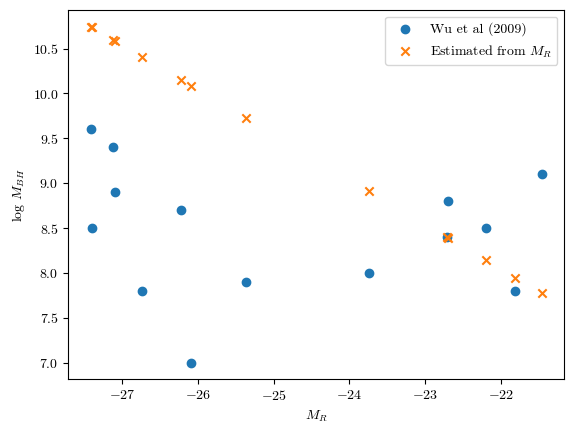

In [40]:
plt.scatter(df_wu_final['M_R'], df_wu_final['logMBH'], label='Wu et al (2009)', marker='o')
plt.scatter(df_wu_final['M_R'], df_wu_final['log_MBH_scaling'], label='Estimated from $M_R$', marker='x')
plt.xlabel(r'$M_R$')
plt.ylabel('log $M_{BH}$')
plt.legend()
plt.show()


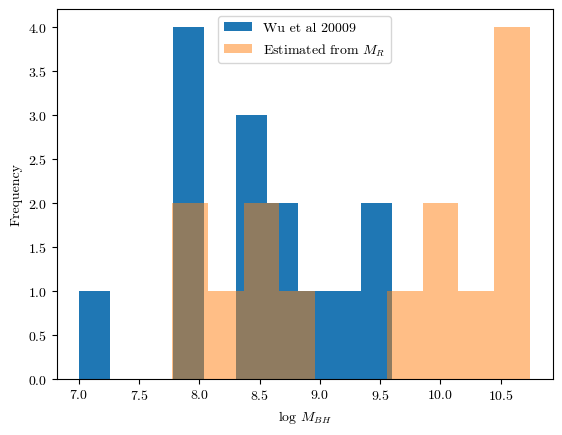

In [34]:
plt.hist(df_wu_final['logMBH'], bins=10, label='Wu et al 20009')
plt.hist(df_wu_final['log_MBH_scaling'], bins=10,label='Estimated from $M_R$',alpha=0.5)
plt.xlabel('log $M_{BH}$')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Eddington Ratio

In [35]:
# M_sun_R = 4.43 (absolute R magnitude of the Sun)
M_sun_R  = 4.43
L_sun    = 3.828e33  # erg/s

df_wu_final['logL_opt'] = (M_sun_R - df_wu_final['M_R']) / 2.5 + np.log10(L_sun)
df_wu_final['logLbol']  = np.log10(10) + df_wu_final['logL_opt']

In [36]:
Edd_L = 1.38e38  # erg/s per solar mass

df_wu_final['log_Edd_calculated'] = np.log10(10**df_wu_final['logLbol'] / (Edd_L * 10**df_wu_final['log_MBH_scaling']))

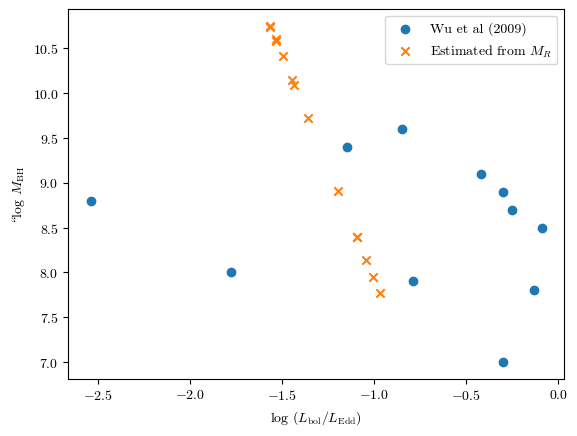

In [49]:
plt.scatter(df_wu_final['logEdd'],df_wu_final['logMBH'], label='Wu et al (2009)', marker='o')
plt.scatter(df_wu_final['log_Edd_calculated'],df_wu_final['log_MBH_scaling'], label='Estimated from $M_R$', marker='x')
plt.ylabel(r'\log $M_{\text{BH}}$')
plt.xlabel(r'log $(L_{\text{bol}}/L_{\text{Edd}})$')
plt.legend()
plt.show()

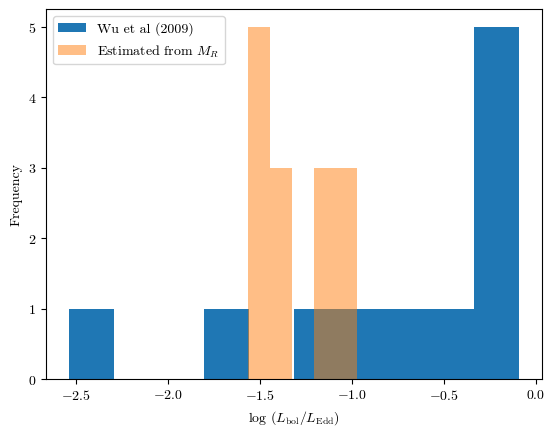

In [51]:
plt.hist(df_wu_final['logEdd'], bins=10, label='Wu et al (2009)')
plt.hist(df_wu_final['log_Edd_calculated'], bins=5, label='Estimated from $M_R$',alpha=0.5)
plt.xlabel(r'log $(L_{\text{bol}}/L_{\text{Edd}})$')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Our R-band-based BH mass moderately agree to the virial masses from Wu et al. (2009). Our estimates tend to be  systematically higher than the Wu values.

This offset is expected given the assumptions above: we use total R-band magnitudes without subtracting the AGN continuum or decomposing the bulge, both of which would reduce the inferred luminosity and hence the BH mass. For the radio-loud sources in this sample (3C and PKS objects, which are predominantly elliptical host galaxies), the bulge $\approx$ total light approximation holds reasonably well, which is why the scatter is not exagerated.

The $M_R$-based Eddington ratios span a narrower range than the Wu et al. (2009) values. This is due to the fact that both $L_{bol}$ and $M_{BH}$ are derived from the same observable, $M_R$, via:

$$M_{BH} \propto 10^{-0.5 M_R}, \quad L_{bol} \propto 10^{-0.4 M_R}$$

Since both scale as power laws of $M_R$, their ratio (the Eddington ratio) has its dynamic range compressed: objects that are intrinsically more  luminous also appear more massive by the same measure, partially cancelling in the Eddington ratio. 

### References

Wu Q (2009) The black hole mass, Eddington ratio and MBH -σ[O iii] relation in young radio galaxies. Monthly Notices of the Royal Astronomical Society 398:1905–1914. https://doi.org/10.1111/j.1365-2966.2009.15127.x

Greene JE, Ho LC (2005) Estimating Black Hole Masses in Active Galaxies Using the Hα Emission Line. The Astrophysical Journal 630:122–129. https://doi.org/10.1086/431897

Shen Y, Richards GT, Strauss MA, et al (2011) A Catalog of Quasar Properties from Sloan Digital Sky Survey Data Release 7. The Astrophysical Journal Supplement Series 194:45. https://doi.org/10.1088/0067-0049/194/2/45

McLure RJ, Dunlop JS (2002) On the black hole-bulge mass relation in active and inactive galaxies. Mon Not R Astron Soc 331:795–804. https://doi.org/10.1046/j.1365-8711.2002.05236.x
